In [12]:
#pip install nltk 
#pip install spacy
#pip install requests beautifulsoup4
# pip install textblob
# pip install wordcloud


In [13]:
import pandas as pd 
from matplotlib import pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
import spacy

# nltk lemmatizer funktioniert nicht mit deutsch, deshalb nur zum Testen verwendet
from nltk.stem import WordNetLemmatizer

# nur zum rumspielen benutzt 
from collections import Counter 

In [14]:
# Einlesen der Daten 
all_parties_df = pd.read_parquet(r"C:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme\all_parties_text_combined.parquet")

In [35]:
wahlomat_theses_df= pd.read_parquet(r"C:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme\wahlomaten_thesen_positionen.parquet")

## Spielereien

In [36]:
import nltk
from nltk.tokenize import word_tokenize

# Lade Punkt-Daten manuell
nltk.download('punkt', download_dir=r'C:\Users\Franziska Rudolf\Documents\Masterstudium Unterlagen\Text Mining\Textmining_Wahlprogramme\pupu\nltk_data')

# Versuch die Tokenisierung
test_text = all_parties_df.loc[230, "Text"]
words = word_tokenize(test_text)
print(words)


['Um', 'die', 'Klimaziele', 'zu', 'erreichen', ',', 'braucht', 'Europa', 'eine', 'echte', 'Energieunion', 'mit', 'effizienter', 'und', 'nachhaltiger', 'Energieversorgung', ',', 'die', 'die', 'Potenziale', 'und', 'Kostenvorteile', 'der', 'Erneuerbaren', 'auf', 'dem', 'gesamten', 'Kontinent', 'nutzt', 'und', 'miteinander', 'verbindet', '.', 'Wir', 'wollen', 'deshalb', 'jetzt', '–', 'von', 'der', 'Sonnenenergie', 'aus', 'Andalusien', 'bis', 'hin', 'zum', 'Wind', 'über', 'der', 'Nordsee', '–', 'die', 'erneuerbaren', 'Energien', ',', 'die', 'Stromnetze', 'und', 'das', 'Wasserstoffkernnetz', 'in', 'ganz', 'Europa', 'ausbauen', '.']


[nltk_data] Downloading package punkt to C:\Users\Franziska
[nltk_data]     Rudolf\Documents\Masterstudium Unterlagen\Text
[nltk_data]     Mining\Textmining_Wahlprogramme\pupu\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


(array([10., 26.,  6.,  6.,  3.,  6.,  5.,  1.,  1.,  1.]),
 array([ 1. ,  2.8,  4.6,  6.4,  8.2, 10. , 11.8, 13.6, 15.4, 17.2, 19. ]),
 <BarContainer object of 10 artists>)

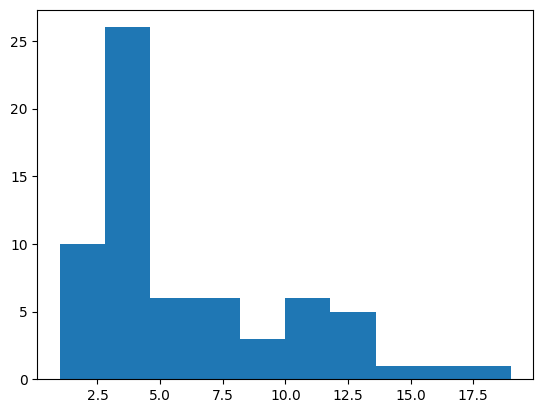

In [22]:

# Testen der Stopwordentfernung an einem Beispiel
test_text = all_parties_df.loc[230, "Text"]

# einfache Analyse der Wortanzahlen 
words = word_tokenize(test_text)
word_lengths = [len(w) for w in words]
plt.hist(word_lengths)



In [23]:
# EInfaches Zählen der Wörter im Text
tokens = word_tokenize(test_text)
lower_tokens = [t.lower() for t in tokens]
bow_simple = Counter(lower_tokens)
print(bow_simple.most_common(10))


[('die', 5), ('und', 4), (',', 3), ('der', 3), ('europa', 2), ('erneuerbaren', 2), ('.', 2), ('–', 2), ('um', 1), ('klimaziele', 1)]


In [25]:
nltk.download('stopwords')
# Bag of Words test mit entfernen der Stopwords 
tokens = [w for w in word_tokenize(test_text.lower())
                if w.isalpha() ]

no_stops = [t for t in tokens
                    if t not in stopwords.words('german')]
bow = Counter(no_stops) 

print(bow.most_common(10))

[('europa', 2), ('erneuerbaren', 2), ('klimaziele', 1), ('erreichen', 1), ('braucht', 1), ('echte', 1), ('energieunion', 1), ('effizienter', 1), ('nachhaltiger', 1), ('energieversorgung', 1)]


[nltk_data] Downloading package stopwords to c:\Users\Franziska
[nltk_data]     Rudolf\Documents\Masterstudium Unterlagen\Text
[nltk_data]     Mining\Textmining_Wahlprogramme\pupu\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [27]:
nltk.download('wordnet')
# Lemmatisieren der Wörter - Test mit NLTK
wordnet_lemmatizer = WordNetLemmatizer()
lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops]

bow = Counter(lemmatized)
print(bow.most_common(10))

[nltk_data] Downloading package wordnet to c:\Users\Franziska
[nltk_data]     Rudolf\Documents\Masterstudium Unterlagen\Text
[nltk_data]     Mining\Textmining_Wahlprogramme\pupu\nltk_data...


[('europa', 2), ('erneuerbaren', 2), ('klimaziele', 1), ('erreichen', 1), ('braucht', 1), ('echte', 1), ('energieunion', 1), ('effizienter', 1), ('nachhaltiger', 1), ('energieversorgung', 1)]


In [29]:
# Lemmatisieren der Wörter mit Spacy 
nlp = spacy.load("de_core_news_sm")
doc = nlp(test_text)
lemmatized = [token.lemma_ for token in doc]

print(lemmatized)

['um', 'der', 'Klimaziele', 'zu', 'erreichen', '--', 'brauchen', 'Europa', 'ein', 'echt', 'Energieunion', 'mit', 'effizient', 'und', 'nachhaltig', 'Energieversorgung', '--', 'der', 'der', 'Potenzial', 'und', 'Kostenvorteil', 'der', 'Erneuerbar', 'auf', 'der', 'gesamt', 'Kontinent', 'nutzen', 'und', 'miteinander', 'verbinden', '--', 'wir', 'wollen', 'deshalb', 'jetzt', '--', 'von', 'der', 'Sonnenenergie', 'aus', 'Andalusien', 'bis', 'hin', 'zu', 'Wind', 'über', 'der', 'Nordsee', '--', 'der', 'erneuerbar', 'Energie', '--', 'der', 'Stromnetze', 'und', 'der', 'Wasserstoffkernnetz', 'in', 'ganz', 'Europa', 'ausbauen', '--']


## Main 

In [30]:
# Entfernen der Stopwords und Satzzeichen, Zahlen sollen erhalten bleiben, da potentiell weiterer Nutzen
def remove_stopwords(text): 
    if pd.isna(text) or text.strip() == "":  
        return ""

    tokens = [w for w in word_tokenize(text.lower())
                if w.isalnum() ]

    no_stops = [t for t in tokens
                    if t not in stopwords.words('german')]
    return " ".join(no_stops)

all_parties_df["Text_no_stopwords"] = all_parties_df["Text"].apply(remove_stopwords)
all_parties_df["These_no_stopwords"] = all_parties_df["These"].apply(remove_stopwords)

In [31]:
# Lemmatisieren der Texte mit Spacy
def lemmatize_words(text): 
    text = text.lower()
    doc = nlp(text)
    lemmatized = [token.lemma_ for token in doc]
    return " ".join(lemmatized)

nlp = spacy.load("de_core_news_md")
all_parties_df["Text_lemmatized"] = all_parties_df["Text_no_stopwords"].apply(lemmatize_words)
all_parties_df["These_lemmatized"] = all_parties_df["These_no_stopwords"].apply(lemmatize_words)

In [32]:
# Entfernen von Duplikaten in Thesen
def remove_duplicate_words(text):
    if pd.isna(text) or text.strip() == "":
        return "", 0 

    words = text.split()
    unique_words = list(dict.fromkeys(words)) 
    removed_count = len(words) - len(unique_words)
    return " ".join(unique_words), removed_count

all_parties_df["These_unique_words"], all_parties_df["Removed_Word_Count"] = zip(
    *all_parties_df["These_lemmatized"].apply(remove_duplicate_words)
)

In [33]:
all_parties_df = all_parties_df.drop(columns=["Removed_Word_Count"])

In [34]:
file_name = 'all_parties_text_combined_prep.parquet' 
all_parties_df.to_parquet(file_name, index=False)

### Überarbeitung Wahlomat Thesen

In [37]:
# Entfernen der Stopwords und Satzzeichen, Zahlen sollen erhalten bleiben, da potentiell weiterer Nutzen
def remove_stopwords(text): 
    if pd.isna(text) or text.strip() == "":  
        return ""

    tokens = [w for w in word_tokenize(text.lower())
                if w.isalnum() ]

    no_stops = [t for t in tokens
                    if t not in stopwords.words('german')]
    return " ".join(no_stops)

wahlomat_theses_df["These_no_stopwords"] = wahlomat_theses_df["These"].apply(remove_stopwords)


In [38]:
# Lemmatisieren der Texte mit Spacy
def lemmatize_words(text): 
    text = text.lower()
    doc = nlp(text)
    lemmatized = [token.lemma_ for token in doc]
    return " ".join(lemmatized)

nlp = spacy.load("de_core_news_md")
wahlomat_theses_df["These_lemmatized"] = wahlomat_theses_df["These_no_stopwords"].apply(lemmatize_words)


In [39]:
# Entfernen von Duplikaten in Thesen
def remove_duplicate_words(text):
    if pd.isna(text) or text.strip() == "":
        return "", 0 

    words = text.split()
    unique_words = list(dict.fromkeys(words)) 
    removed_count = len(words) - len(unique_words)
    return " ".join(unique_words), removed_count

wahlomat_theses_df["These_unique_words"], wahlomat_theses_df["Removed_Word_Count"] = zip(
    *wahlomat_theses_df["These_lemmatized"].apply(remove_duplicate_words)
)

In [40]:
wahlomat_theses_df = wahlomat_theses_df.drop(columns=["Removed_Word_Count"])

In [43]:
file_name = 'wahlomat_thesen_prep.parquet' 
wahlomat_theses_df.to_parquet(file_name, index=False)

In [44]:
import pandas as pd

# Einlesen der Parquet-Datei
loaded_df = pd.read_parquet('wahlomat_thesen_prep.parquet')

# Anzeigen des geladenen DataFrames
print(loaded_df.head())  # Zeigt die ersten 5 Zeilen des DataFrames an


                                               These        CDU / CSU  \
0  Alle Beschäftigten sollen bereits nach 40 Beit...  stimme nicht zu   
1  Alle Bürgerinnen und Bürger sollen in gesetzli...  stimme nicht zu   
2  An Bahnhöfen soll die Bundespolizei Software z...        stimme zu   
3  Asylsuchende sollen in Deutschland sofort nach...  stimme nicht zu   
4  Asylsuchende, die über einen anderen EU-Staat ...        stimme zu   

             GRÜNE              SPD              AfD        Die Linke  \
0  stimme nicht zu  stimme nicht zu  stimme nicht zu        stimme zu   
1        stimme zu        stimme zu  stimme nicht zu        stimme zu   
2  stimme nicht zu  stimme nicht zu        stimme zu  stimme nicht zu   
3        stimme zu        stimme zu  stimme nicht zu        stimme zu   
4  stimme nicht zu  stimme nicht zu        stimme zu  stimme nicht zu   

               FDP                                 These_no_stopwords  \
0  stimme nicht zu  beschäftigten sollen bereits 